Loading cleaned_data.csv...
Original Row Count: 859927
Rows available for analysis: 859927

--- RQ2 Analysis ---
Spearman Correlation: 0.1891, P-value: 0.0000e+00
✅ Saved rq2_stars_time.png

--- RQ3 Analysis ---
✅ Saved rq3_boxplot.png
⚠️ Cannot run regression: Data contains only one class (all merged or all closed).


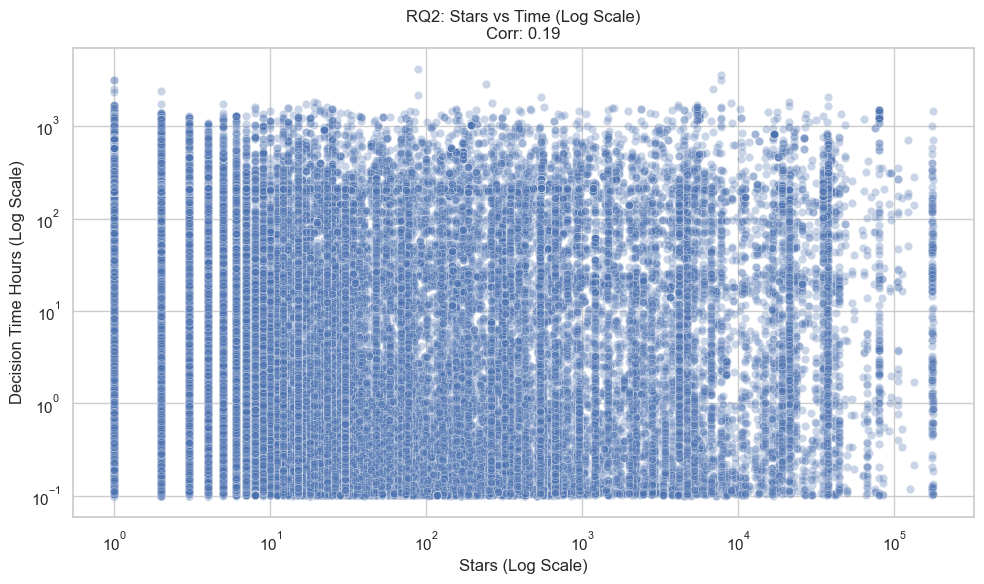

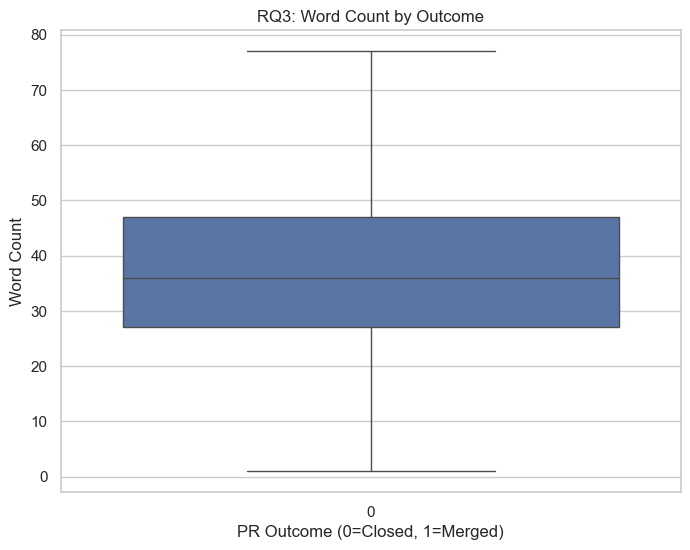

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys

# Attempt to import necessary libraries; prompt user if missing
try:
    from scipy.stats import spearmanr
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
except ImportError:
    print("❌ Missing libraries. Please run: pip install scipy scikit-learn")
    sys.exit(1)

def final_analysis(input_file):
    print(f"Loading {input_file}...")
    try:
        df = pd.read_csv(input_file)
    except FileNotFoundError:
        print(f"Error: {input_file} not found.")
        return

    # 1. Basic Validation
    print(f"Original Row Count: {len(df)}")
    required_cols = ['decision_time_hours', 'stars', 'body_word_count', 'is_merged']
    
    # Check for missing columns
    for col in required_cols:
        if col not in df.columns:
            print(f"❌ Critical Error: Column '{col}' is missing.")
            return

    # 2. Smart Data Cleaning
    # Instead of dropping everything, we clean carefully
    df_clean = df.copy()
    
    # Handle Stars: Fill NaN with 0 (assuming missing means 0 stars)
    df_clean['stars'] = df_clean['stars'].fillna(0)
    
    # Handle Time: Must have valid time data
    df_clean = df_clean.dropna(subset=['decision_time_hours'])
    
    # Handle Merged status: Must have status
    df_clean = df_clean.dropna(subset=['is_merged'])
    
    print(f"Rows available for analysis: {len(df_clean)}")
    
    if len(df_clean) < 5:
        print("❌ Error: Not enough data points (<5) to plot charts.")
        print("Please check cleaning.py merging logic.")
        return

    sns.set(style="whitegrid")

    # ==========================================
    # RQ2: Stars vs Time
    # ==========================================
    print("\n--- RQ2 Analysis ---")
    try:
        # Check if all stars are 0 (indicates merge failure in cleaning step)
        if df_clean['stars'].sum() == 0:
            print("⚠️ Warning: All 'stars' are 0. Merging likely failed in cleaning step.")
            print("Skipping RQ2 plot to avoid crash.")
        else:
            # Add 1 to avoid log(0) errors
            x_data = df_clean['stars'] + 1
            y_data = df_clean['decision_time_hours'] + 0.1
            
            # Calculate Correlation
            corr, p_value = spearmanr(df_clean['stars'], df_clean['decision_time_hours'])
            print(f"Spearman Correlation: {corr:.4f}, P-value: {p_value:.4e}")

            # Plot Scatter
            plt.figure(figsize=(10, 6))
            sns.scatterplot(x=x_data, y=y_data, alpha=0.3)
            plt.xscale('log') 
            plt.yscale('log')
            plt.title(f'RQ2: Stars vs Time (Log Scale)\nCorr: {corr:.2f}')
            plt.xlabel('Stars (Log Scale)')
            plt.ylabel('Decision Time Hours (Log Scale)')
            plt.tight_layout()
            plt.savefig('rq2_stars_time.png', dpi=300)
            print("✅ Saved rq2_stars_time.png")
            
    except Exception as e:
        print(f"❌ RQ2 Plot Failed: {e}")

    # ==========================================
    # RQ3: Word Count vs Outcome
    # ==========================================
    print("\n--- RQ3 Analysis ---")
    try:
        # Plot Boxplot
        plt.figure(figsize=(8, 6))
        sns.boxplot(x='is_merged', y='body_word_count', data=df_clean, showfliers=False)
        plt.title('RQ3: Word Count by Outcome')
        plt.xlabel('PR Outcome (0=Closed, 1=Merged)')
        plt.ylabel('Word Count')
        plt.savefig('rq3_boxplot.png', dpi=300)
        print("✅ Saved rq3_boxplot.png")

        # Logistic Regression Model
        if df_clean['is_merged'].nunique() < 2:
            print("⚠️ Cannot run regression: Data contains only one class (all merged or all closed).")
        else:
            X = df_clean[['body_word_count']].fillna(0)
            y = df_clean['is_merged']
            
            model = LogisticRegression()
            model.fit(X, y)
            print(f"Logistic Regression Coef: {model.coef_[0][0]:.4f}")
            
    except Exception as e:
        print(f"❌ RQ3 Analysis Failed: {e}")

if __name__ == "__main__":
    final_analysis('cleaned_data.csv')